train: (50000, 32, 32, 3) test: (10000, 32, 32, 3)
dtype: uint8 min: 0 max: 255
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

count per class (train | test):
  0   airplane |  5000 |  1000
  1 automobile |  5000 |  1000
  2       bird |  5000 |  1000
  3        cat |  5000 |  1000
  4       deer |  5000 |  1000
  5        dog |  5000 |  1000
  6       frog |  5000 |  1000
  7      horse |  5000 |  1000
  8       ship |  5000 |  1000
  9      truck |  5000 |  1000


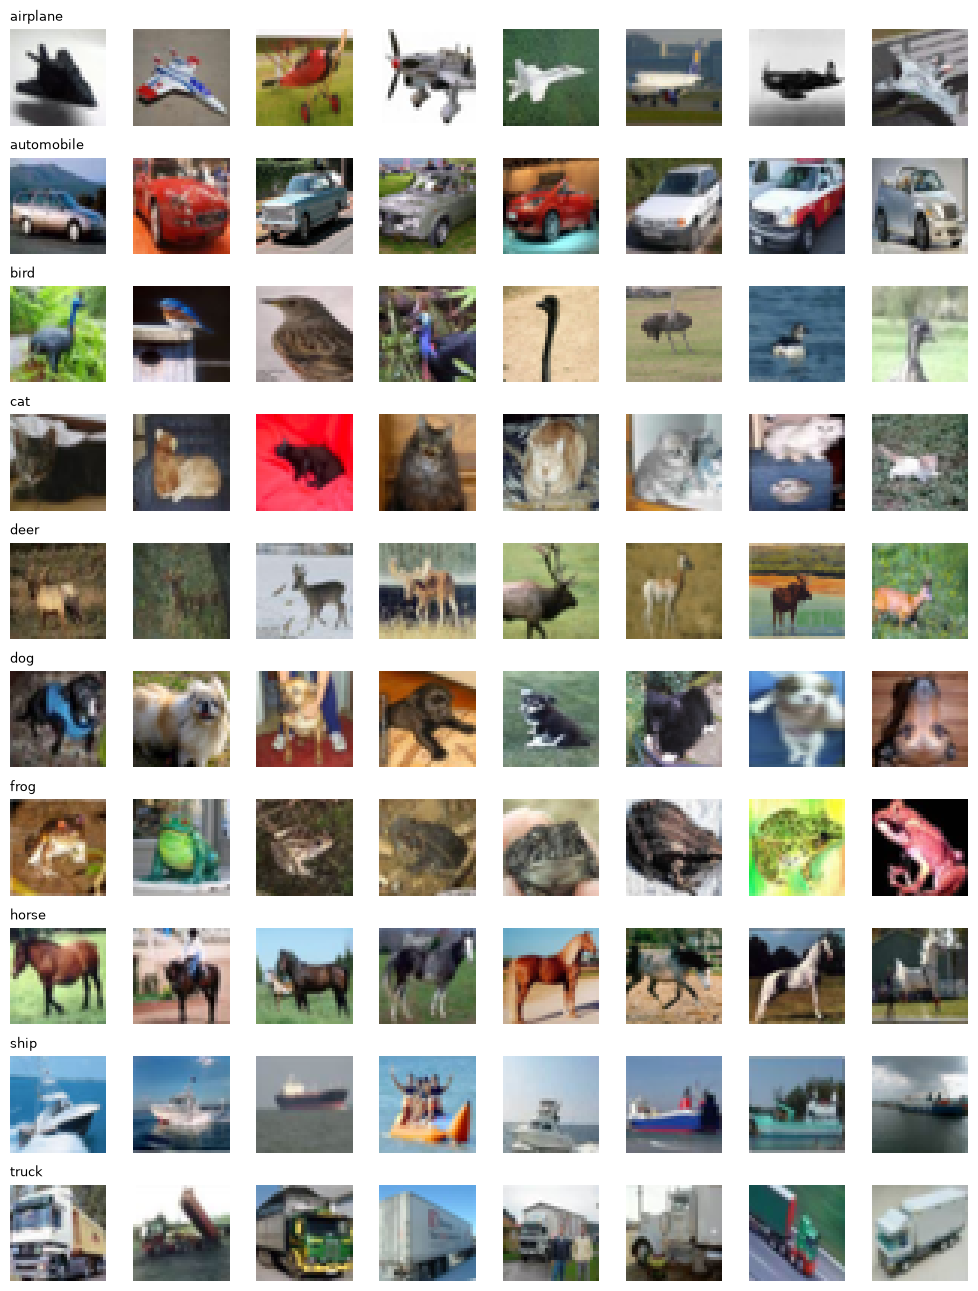

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

train = datasets.CIFAR10(root="./data", train=True, download=True)
test = datasets.CIFAR10(root="./data", train=False, download=True)

Xtr, ytr = train.data, np.array(train.targets)
Xte, yte = test.data, np.array(test.targets)
classes = train.classes

print("train:", Xtr.shape, "test:", Xte.shape)
print("dtype:", Xtr.dtype, "min:", Xtr.min(), "max:", Xtr.max())
print("classes:", classes)

print("\ncount per class (train | test):")
for i, name in enumerate(classes):
    print(f"  {i} {name:>10} | {np.sum(ytr == i):>5} | {np.sum(yte == i):>5}")

fig, axes = plt.subplots(10, 8, figsize=(10, 13))
for i, name in enumerate(classes):
    idx = np.where(ytr == i)[0][:8]
    for j, k in enumerate(idx):
        ax = axes[i, j]
        ax.imshow(Xtr[k])
        ax.axis("off")
        if j == 0:
            ax.set_title(name, fontsize=9, loc="left")
plt.tight_layout()
plt.show()

In [2]:
import torch

Xtr_f = Xtr.astype(np.float32) / 255.0
Xte_f = Xte.astype(np.float32) / 255.0

mean = Xtr_f.mean(axis=(0, 1, 2))
std = Xtr_f.std(axis=(0, 1, 2))
print("mean per channel:", mean)
print("std per channel: ", std)

Xtr_n = (Xtr_f - mean) / std
Xte_n = (Xte_f - mean) / std

Xtr_t = torch.tensor(Xtr_n).permute(0, 3, 1, 2)
Xte_t = torch.tensor(Xte_n).permute(0, 3, 1, 2)
ytr_t = torch.tensor(ytr, dtype=torch.long)
yte_t = torch.tensor(yte, dtype=torch.long)

print("\ntrain:", Xtr_t.shape, Xtr_t.dtype)
print("test: ", Xte_t.shape, Xte_t.dtype)
print("\ncheck train mean:", Xtr_t.mean(dim=(0, 2, 3)))
print("check train std: ", Xtr_t.std(dim=(0, 2, 3)))
print("check test mean: ", Xte_t.mean(dim=(0, 2, 3)))

mean per channel: [0.4914009  0.48215896 0.4465308 ]
std per channel:  [0.24703279 0.24348423 0.26158753]

train: torch.Size([50000, 3, 32, 32]) torch.float32
test:  torch.Size([10000, 3, 32, 32]) torch.float32

check train mean: tensor([-4.9021e-06, -2.2221e-06,  5.1427e-07])
check train std:  tensor([1.0000, 1.0000, 1.0000])
check test mean:  tensor([0.0114, 0.0122, 0.0148])


In [3]:
import gc

rng = np.random.default_rng(0)
val_idx = []
for c in range(10):
    idx_c = np.where(ytr == c)[0]
    val_idx.extend(rng.choice(idx_c, 500, replace=False))
val_idx = np.array(val_idx)
tr_idx = np.setdiff1d(np.arange(len(ytr)), val_idx)

Xa, ya = Xtr[tr_idx], ytr[tr_idx]
Xv, yv = Xtr[val_idx], ytr[val_idx]

mean = (Xa.astype(np.float32) / 255.0).mean(axis=(0, 1, 2))
std = (Xa.astype(np.float32) / 255.0).std(axis=(0, 1, 2))

def prep(X):
    Xn = (X.astype(np.float32) / 255.0 - mean) / std
    return torch.tensor(Xn).permute(0, 3, 1, 2)

Xa_t, Xv_t, Xte_t = prep(Xa), prep(Xv), prep(Xte)
ya_t = torch.tensor(ya, dtype=torch.long)
yv_t = torch.tensor(yv, dtype=torch.long)
yte_t = torch.tensor(yte, dtype=torch.long)

del Xtr_t, ytr_t
gc.collect()

print("train:", Xa_t.shape, "val:", Xv_t.shape, "test:", Xte_t.shape)
print("val per class:", np.bincount(yv))
print("train per class:", np.bincount(ya))
print("mean:", mean, "std:", std)

train: torch.Size([45000, 3, 32, 32]) val: torch.Size([5000, 3, 32, 32]) test: torch.Size([10000, 3, 32, 32])
val per class: [500 500 500 500 500 500 500 500 500 500]
train per class: [4500 4500 4500 4500 4500 4500 4500 4500 4500 4500]
mean: [0.49161914 0.48231646 0.44687825] std: [0.24723086 0.24366921 0.26172727]


In [4]:
import time
import torch.nn as nn

device = "cuda"
torch.manual_seed(0)

Xa_g, ya_g = Xa_t.to(device), ya_t.to(device)
Xv_g, yv_g = Xv_t.to(device), yv_t.to(device)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3072, 512), nn.ReLU(),
    nn.Linear(512, 256), nn.ReLU(),
    nn.Linear(256, 10),
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print("params:", n_params)

loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(X, y, bs=1000):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for i in range(0, len(X), bs):
            out = model(X[i:i+bs])
            total_loss += loss_fn(out, y[i:i+bs]).item() * len(out)
            correct += (out.argmax(1) == y[i:i+bs]).sum().item()
    return total_loss / len(X), correct / len(X)

vl, va = evaluate(Xv_g, yv_g)
print(f"before training | val loss {vl:.3f} | val acc {va:.3f}")

hist = []
BS, EPOCHS = 128, 15
for ep in range(EPOCHS):
    t0 = time.time()
    model.train()
    perm = torch.randperm(len(Xa_g), device=device)
    for i in range(0, len(perm), BS):
        idx = perm[i:i+BS]
        out = model(Xa_g[idx])
        loss = loss_fn(out, ya_g[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
    tl, ta = evaluate(Xa_g, ya_g)
    vl, va = evaluate(Xv_g, yv_g)
    hist.append((tl, ta, vl, va))
    print(f"ep {ep+1:>2} | train {tl:.3f} {ta:.3f} | val {vl:.3f} {va:.3f} | {time.time()-t0:.1f}s")

params: 1707274
before training | val loss 2.310 | val acc 0.085
ep  1 | train 1.461 0.486 | val 1.548 0.459 | 0.9s
ep  2 | train 1.323 0.532 | val 1.462 0.496 | 0.6s
ep  3 | train 1.218 0.566 | val 1.407 0.501 | 0.7s
ep  4 | train 1.149 0.597 | val 1.430 0.505 | 0.7s
ep  5 | train 1.041 0.633 | val 1.376 0.532 | 0.7s
ep  6 | train 0.982 0.653 | val 1.386 0.522 | 0.7s
ep  7 | train 0.907 0.677 | val 1.413 0.537 | 0.7s
ep  8 | train 0.820 0.710 | val 1.460 0.526 | 0.7s
ep  9 | train 0.749 0.737 | val 1.456 0.540 | 0.7s
ep 10 | train 0.713 0.749 | val 1.536 0.535 | 0.7s
ep 11 | train 0.659 0.769 | val 1.533 0.536 | 0.7s
ep 12 | train 0.591 0.791 | val 1.632 0.538 | 0.7s
ep 13 | train 0.571 0.799 | val 1.709 0.534 | 0.7s
ep 14 | train 0.508 0.823 | val 1.779 0.532 | 0.7s
ep 15 | train 0.466 0.836 | val 1.874 0.530 | 0.7s


In [ ]:
def make_cnn():
    return nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
        nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
        nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
        nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),
        nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
        nn.Linear(256, 10),
    )

def run(model, epochs=15, bs=128, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    print("params:", sum(p.numel() for p in model.parameters()))

    def evaluate(X, y, eb=1000):
        model.eval()
        tot, cor = 0.0, 0
        with torch.no_grad():
            for i in range(0, len(X), eb):
                out = model(X[i:i+eb])
                tot += loss_fn(out, y[i:i+eb]).item() * len(out)
                cor += (out.argmax(1) == y[i:i+eb]).sum().item()
        return tot / len(X), cor / len(X)

    vl, va = evaluate(Xv_g, yv_g)
    print(f"before training | val loss {vl:.3f} | val acc {va:.3f}")

    hist = []
    for ep in range(epochs):
        t0 = time.time()
        model.train()
        perm = torch.randperm(len(Xa_g), device=device)
        for i in range(0, len(perm), bs):
            idx = perm[i:i+bs]
            loss = loss_fn(model(Xa_g[idx]), ya_g[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
        tl, ta = evaluate(Xa_g, ya_g)
        vl, va = evaluate(Xv_g, yv_g)
        hist.append((tl, ta, vl, va))
        print(f"ep {ep+1:>2} | train {tl:.3f} {ta:.3f} | val {vl:.3f} {va:.3f} | {time.time()-t0:.1f}s")
    return model, hist

torch.manual_seed(0)
cnn, hist_cnn = run(make_cnn())

params: 814122
before training | val loss 2.303 | val acc 0.100
ep  1 | train 1.276 0.536 | val 1.312 0.526 | 4.3s
ep  2 | train 0.899 0.682 | val 0.962 0.653 | 4.1s
ep  3 | train 0.708 0.749 | val 0.823 0.707 | 4.1s
ep  4 | train 0.677 0.762 | val 0.851 0.717 | 4.1s
ep  5 | train 0.538 0.817 | val 0.724 0.748 | 4.1s
ep  6 | train 0.422 0.856 | val 0.701 0.756 | 4.1s
ep  7 | train 0.344 0.884 | val 0.697 0.758 | 4.1s
ep  8 | train 0.275 0.904 | val 0.793 0.757 | 4.1s
ep  9 | train 0.209 0.927 | val 0.790 0.769 | 4.1s
ep 10 | train 0.154 0.946 | val 0.862 0.765 | 4.1s
ep 11 | train 0.139 0.952 | val 0.919 0.760 | 4.1s
ep 12 | train 0.116 0.960 | val 0.952 0.763 | 4.1s
ep 13 | train 0.105 0.964 | val 1.098 0.755 | 4.1s
ep 14 | train 0.078 0.974 | val 1.103 0.766 | 4.1s
ep 15 | train 0.096 0.966 | val 1.223 0.763 | 4.1s


In [6]:
import torch.nn.functional as F

def augment_batch(x):
    n = x.size(0)
    dev = x.device
    flip = torch.rand(n, device=dev) < 0.5
    x = torch.where(flip[:, None, None, None], x.flip(3), x)
    xp = F.pad(x, (4, 4, 4, 4))
    i = torch.randint(0, 9, (n,), device=dev)
    j = torch.randint(0, 9, (n,), device=dev)
    ar = torch.arange(32, device=dev)
    rows = i[:, None] + ar[None, :]
    cols = j[:, None] + ar[None, :]
    b = torch.arange(n, device=dev)[:, None, None, None]
    c = torch.arange(3, device=dev)[None, :, None, None]
    return xp[b, c, rows[:, None, :, None], cols[:, None, None, :]]

def run(model, epochs=15, bs=128, lr=1e-3, augment=False):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    print("params:", sum(p.numel() for p in model.parameters()))

    def evaluate(X, y, eb=1000):
        model.eval()
        tot, cor = 0.0, 0
        with torch.no_grad():
            for i in range(0, len(X), eb):
                out = model(X[i:i+eb])
                tot += loss_fn(out, y[i:i+eb]).item() * len(out)
                cor += (out.argmax(1) == y[i:i+eb]).sum().item()
        return tot / len(X), cor / len(X)

    vl, va = evaluate(Xv_g, yv_g)
    print(f"before training | val loss {vl:.3f} | val acc {va:.3f}")

    hist = []
    for ep in range(epochs):
        t0 = time.time()
        model.train()
        perm = torch.randperm(len(Xa_g), device=device)
        for i in range(0, len(perm), bs):
            idx = perm[i:i+bs]
            xb = Xa_g[idx]
            if augment:
                xb = augment_batch(xb)
            loss = loss_fn(model(xb), ya_g[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
        tl, ta = evaluate(Xa_g, ya_g)
        vl, va = evaluate(Xv_g, yv_g)
        hist.append((tl, ta, vl, va))
        print(f"ep {ep+1:>2} | train {tl:.3f} {ta:.3f} | val {vl:.3f} {va:.3f} | {time.time()-t0:.1f}s")
    return model, hist

torch.manual_seed(0)
cnn_aug, hist_aug = run(make_cnn(), augment=True)

params: 814122
before training | val loss 2.303 | val acc 0.100
ep  1 | train 1.311 0.520 | val 1.334 0.510 | 4.3s
ep  2 | train 1.072 0.612 | val 1.096 0.600 | 4.2s
ep  3 | train 0.876 0.687 | val 0.913 0.671 | 4.3s
ep  4 | train 0.809 0.713 | val 0.871 0.696 | 4.3s
ep  5 | train 0.673 0.760 | val 0.762 0.733 | 4.2s
ep  6 | train 0.629 0.778 | val 0.714 0.748 | 4.2s
ep  7 | train 0.576 0.797 | val 0.665 0.776 | 4.1s
ep  8 | train 0.519 0.818 | val 0.623 0.787 | 4.2s
ep  9 | train 0.532 0.813 | val 0.635 0.775 | 4.2s
ep 10 | train 0.469 0.836 | val 0.569 0.808 | 4.1s
ep 11 | train 0.467 0.834 | val 0.564 0.805 | 4.1s
ep 12 | train 0.418 0.853 | val 0.546 0.819 | 4.1s
ep 13 | train 0.410 0.858 | val 0.539 0.822 | 4.1s
ep 14 | train 0.389 0.864 | val 0.516 0.822 | 4.1s
ep 15 | train 0.406 0.857 | val 0.563 0.812 | 4.1s


In [7]:
torch.manual_seed(0)
cnn_aug40, hist_aug40 = run(make_cnn(), epochs=40, augment=True)

params: 814122
before training | val loss 2.303 | val acc 0.100
ep  1 | train 1.348 0.503 | val 1.368 0.495 | 4.3s
ep  2 | train 1.097 0.606 | val 1.124 0.594 | 4.2s
ep  3 | train 0.948 0.663 | val 0.973 0.652 | 4.1s
ep  4 | train 0.772 0.730 | val 0.822 0.706 | 4.1s
ep  5 | train 0.655 0.768 | val 0.735 0.744 | 4.1s
ep  6 | train 0.621 0.782 | val 0.697 0.754 | 4.1s
ep  7 | train 0.630 0.781 | val 0.705 0.759 | 4.1s
ep  8 | train 0.516 0.821 | val 0.612 0.794 | 4.1s
ep  9 | train 0.496 0.825 | val 0.599 0.792 | 4.1s
ep 10 | train 0.460 0.838 | val 0.558 0.812 | 4.1s
ep 11 | train 0.453 0.839 | val 0.571 0.808 | 4.1s
ep 12 | train 0.406 0.858 | val 0.526 0.817 | 4.2s
ep 13 | train 0.447 0.845 | val 0.566 0.811 | 4.2s
ep 14 | train 0.401 0.860 | val 0.529 0.817 | 4.2s
ep 15 | train 0.378 0.867 | val 0.520 0.825 | 4.2s
ep 16 | train 0.379 0.866 | val 0.550 0.820 | 4.2s
ep 17 | train 0.344 0.879 | val 0.509 0.828 | 4.2s
ep 18 | train 0.336 0.882 | val 0.510 0.831 | 4.1s
ep 19 | train 0.33

In [8]:
def run(model, epochs=15, bs=128, lr=1e-3, augment=False, cosine=False):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs) if cosine else None
    print("params:", sum(p.numel() for p in model.parameters()))

    def evaluate(X, y, eb=1000):
        model.eval()
        tot, cor = 0.0, 0
        with torch.no_grad():
            for i in range(0, len(X), eb):
                out = model(X[i:i+eb])
                tot += loss_fn(out, y[i:i+eb]).item() * len(out)
                cor += (out.argmax(1) == y[i:i+eb]).sum().item()
        return tot / len(X), cor / len(X)

    vl, va = evaluate(Xv_g, yv_g)
    print(f"before training | val loss {vl:.3f} | val acc {va:.3f}")

    hist = []
    for ep in range(epochs):
        t0 = time.time()
        model.train()
        perm = torch.randperm(len(Xa_g), device=device)
        for i in range(0, len(perm), bs):
            idx = perm[i:i+bs]
            xb = Xa_g[idx]
            if augment:
                xb = augment_batch(xb)
            loss = loss_fn(model(xb), ya_g[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
        cur_lr = opt.param_groups[0]["lr"]
        if sched:
            sched.step()
        tl, ta = evaluate(Xa_g, ya_g)
        vl, va = evaluate(Xv_g, yv_g)
        hist.append((tl, ta, vl, va))
        print(f"ep {ep+1:>2} | lr {cur_lr:.6f} | train {tl:.3f} {ta:.3f} | val {vl:.3f} {va:.3f} | {time.time()-t0:.1f}s")
    return model, hist

torch.manual_seed(0)
cnn_cos, hist_cos = run(make_cnn(), epochs=40, augment=True, cosine=True)

params: 814122
before training | val loss 2.303 | val acc 0.100
ep  1 | lr 0.001000 | train 1.311 0.519 | val 1.332 0.504 | 4.3s
ep  2 | lr 0.000998 | train 1.072 0.615 | val 1.103 0.612 | 4.2s
ep  3 | lr 0.000994 | train 0.905 0.674 | val 0.948 0.658 | 4.2s
ep  4 | lr 0.000986 | train 0.851 0.702 | val 0.909 0.683 | 4.1s
ep  5 | lr 0.000976 | train 0.678 0.760 | val 0.763 0.737 | 4.1s
ep  6 | lr 0.000962 | train 0.609 0.786 | val 0.685 0.760 | 4.1s
ep  7 | lr 0.000946 | train 0.613 0.783 | val 0.699 0.753 | 4.1s
ep  8 | lr 0.000926 | train 0.538 0.812 | val 0.644 0.782 | 4.1s
ep  9 | lr 0.000905 | train 0.507 0.822 | val 0.605 0.787 | 4.1s
ep 10 | lr 0.000880 | train 0.488 0.830 | val 0.604 0.794 | 4.1s
ep 11 | lr 0.000854 | train 0.451 0.840 | val 0.571 0.809 | 4.1s
ep 12 | lr 0.000825 | train 0.414 0.855 | val 0.532 0.820 | 4.2s
ep 13 | lr 0.000794 | train 0.426 0.852 | val 0.544 0.811 | 4.2s
ep 14 | lr 0.000761 | train 0.386 0.865 | val 0.525 0.823 | 4.1s
ep 15 | lr 0.000727 | trai

In [9]:
def conv_bn(cin, cout):
    return [nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU()]

def make_cnn_bn():
    return nn.Sequential(
        *conv_bn(3, 32), *conv_bn(32, 32), nn.MaxPool2d(2),
        *conv_bn(32, 64), *conv_bn(64, 64), nn.MaxPool2d(2),
        *conv_bn(64, 128), *conv_bn(128, 128), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
        nn.Linear(256, 10),
    )

torch.manual_seed(0)
cnn_bn, hist_bn = run(make_cnn_bn(), epochs=40, augment=True, cosine=True)

params: 814570
before training | val loss 2.303 | val acc 0.100
ep  1 | lr 0.001000 | train 1.314 0.539 | val 1.327 0.532 | 4.9s
ep  2 | lr 0.000998 | train 0.844 0.705 | val 0.904 0.681 | 4.8s
ep  3 | lr 0.000994 | train 0.774 0.733 | val 0.812 0.723 | 4.7s
ep  4 | lr 0.000986 | train 0.722 0.747 | val 0.767 0.733 | 4.7s
ep  5 | lr 0.000976 | train 0.557 0.805 | val 0.640 0.777 | 4.7s
ep  6 | lr 0.000962 | train 0.474 0.834 | val 0.556 0.811 | 4.7s
ep  7 | lr 0.000946 | train 0.484 0.830 | val 0.563 0.803 | 4.7s
ep  8 | lr 0.000926 | train 0.464 0.839 | val 0.576 0.805 | 4.8s
ep  9 | lr 0.000905 | train 0.405 0.860 | val 0.487 0.834 | 4.7s
ep 10 | lr 0.000880 | train 0.445 0.843 | val 0.560 0.803 | 4.7s
ep 11 | lr 0.000854 | train 0.363 0.875 | val 0.469 0.843 | 4.7s
ep 12 | lr 0.000825 | train 0.338 0.882 | val 0.454 0.849 | 4.9s
ep 13 | lr 0.000794 | train 0.336 0.882 | val 0.474 0.840 | 4.8s
ep 14 | lr 0.000761 | train 0.308 0.893 | val 0.446 0.850 | 4.8s
ep 15 | lr 0.000727 | trai

In [10]:
def run(model, epochs=15, bs=128, lr=1e-3, augment=False, cosine=False, opt_name="adam"):
    model = model.to(device)
    if opt_name == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs) if cosine else None
    print("params:", sum(p.numel() for p in model.parameters()))

    def evaluate(X, y, eb=1000):
        model.eval()
        tot, cor = 0.0, 0
        with torch.no_grad():
            for i in range(0, len(X), eb):
                out = model(X[i:i+eb])
                tot += loss_fn(out, y[i:i+eb]).item() * len(out)
                cor += (out.argmax(1) == y[i:i+eb]).sum().item()
        return tot / len(X), cor / len(X)

    vl, va = evaluate(Xv_g, yv_g)
    print(f"before training | val loss {vl:.3f} | val acc {va:.3f}")

    hist = []
    for ep in range(epochs):
        t0 = time.time()
        model.train()
        perm = torch.randperm(len(Xa_g), device=device)
        for i in range(0, len(perm), bs):
            idx = perm[i:i+bs]
            xb = Xa_g[idx]
            if augment:
                xb = augment_batch(xb)
            loss = loss_fn(model(xb), ya_g[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
        cur_lr = opt.param_groups[0]["lr"]
        if sched:
            sched.step()
        tl, ta = evaluate(Xa_g, ya_g)
        vl, va = evaluate(Xv_g, yv_g)
        hist.append((tl, ta, vl, va))
        print(f"ep {ep+1:>2} | lr {cur_lr:.6f} | train {tl:.3f} {ta:.3f} | val {vl:.3f} {va:.3f} | {time.time()-t0:.1f}s")
    return model, hist

torch.manual_seed(0)
cnn_sgd, hist_sgd = run(make_cnn_bn(), epochs=40, lr=0.05, augment=True, cosine=True, opt_name="sgd")

params: 814570
before training | val loss 2.303 | val acc 0.100
ep  1 | lr 0.050000 | train 1.312 0.546 | val 1.313 0.548 | 4.7s
ep  2 | lr 0.049923 | train 0.906 0.682 | val 0.946 0.665 | 4.7s
ep  3 | lr 0.049692 | train 0.857 0.702 | val 0.909 0.677 | 4.7s
ep  4 | lr 0.049309 | train 0.725 0.744 | val 0.778 0.734 | 4.7s
ep  5 | lr 0.048776 | train 0.582 0.796 | val 0.647 0.776 | 4.7s
ep  6 | lr 0.048097 | train 0.533 0.813 | val 0.617 0.787 | 4.6s
ep  7 | lr 0.047275 | train 0.652 0.789 | val 0.730 0.771 | 4.6s
ep  8 | lr 0.046316 | train 0.422 0.852 | val 0.524 0.824 | 4.6s
ep  9 | lr 0.045225 | train 0.459 0.844 | val 0.566 0.813 | 4.6s
ep 10 | lr 0.044010 | train 0.402 0.860 | val 0.515 0.823 | 4.6s
ep 11 | lr 0.042678 | train 0.349 0.877 | val 0.461 0.842 | 4.6s
ep 12 | lr 0.041236 | train 0.315 0.890 | val 0.439 0.852 | 4.7s
ep 13 | lr 0.039695 | train 0.311 0.893 | val 0.440 0.856 | 4.7s
ep 14 | lr 0.038062 | train 0.314 0.891 | val 0.437 0.854 | 4.7s
ep 15 | lr 0.036350 | trai

In [11]:
def make_cnn_bn(p_drop=0.0):
    return nn.Sequential(
        *conv_bn(3, 32), *conv_bn(32, 32), nn.MaxPool2d(2),
        *conv_bn(32, 64), *conv_bn(64, 64), nn.MaxPool2d(2),
        *conv_bn(64, 128), *conv_bn(128, 128), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
        nn.Dropout(p_drop),
        nn.Linear(256, 10),
    )

torch.manual_seed(0)
cnn_drop, hist_drop = run(make_cnn_bn(p_drop=0.3), epochs=40, augment=True, cosine=True)

params: 814570
before training | val loss 2.303 | val acc 0.100
ep  1 | lr 0.001000 | train 1.173 0.579 | val 1.204 0.563 | 4.8s
ep  2 | lr 0.000998 | train 1.220 0.591 | val 1.237 0.586 | 4.8s
ep  3 | lr 0.000994 | train 0.776 0.726 | val 0.839 0.715 | 4.7s
ep  4 | lr 0.000986 | train 0.696 0.756 | val 0.734 0.737 | 4.7s
ep  5 | lr 0.000976 | train 0.752 0.739 | val 0.807 0.722 | 4.7s
ep  6 | lr 0.000962 | train 0.663 0.771 | val 0.715 0.755 | 4.7s
ep  7 | lr 0.000946 | train 0.515 0.820 | val 0.573 0.805 | 4.7s
ep  8 | lr 0.000926 | train 0.457 0.840 | val 0.530 0.819 | 4.7s
ep  9 | lr 0.000905 | train 0.518 0.823 | val 0.582 0.807 | 4.7s
ep 10 | lr 0.000880 | train 0.411 0.856 | val 0.487 0.832 | 4.7s
ep 11 | lr 0.000854 | train 0.392 0.863 | val 0.498 0.835 | 4.7s
ep 12 | lr 0.000825 | train 0.472 0.837 | val 0.576 0.810 | 4.7s
ep 13 | lr 0.000794 | train 0.343 0.880 | val 0.455 0.848 | 4.7s
ep 14 | lr 0.000761 | train 0.340 0.879 | val 0.452 0.842 | 4.7s
ep 15 | lr 0.000727 | trai

In [12]:
import json, itertools

def run(model, epochs=15, bs=128, lr=1e-3, augment=False, cosine=False,
        opt_name="adam", wd=0.0, verbose=True):
    model = model.to(device)
    if opt_name == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    else:
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs) if cosine else None

    def evaluate(X, y, eb=1000):
        model.eval()
        tot, cor = 0.0, 0
        with torch.no_grad():
            for i in range(0, len(X), eb):
                out = model(X[i:i+eb])
                tot += loss_fn(out, y[i:i+eb]).item() * len(out)
                cor += (out.argmax(1) == y[i:i+eb]).sum().item()
        return tot / len(X), cor / len(X)

    hist = []
    for ep in range(epochs):
        t0 = time.time()
        model.train()
        perm = torch.randperm(len(Xa_g), device=device)
        for i in range(0, len(perm), bs):
            idx = perm[i:i+bs]
            xb = Xa_g[idx]
            if augment:
                xb = augment_batch(xb)
            loss = loss_fn(model(xb), ya_g[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
        cur_lr = opt.param_groups[0]["lr"]
        if sched:
            sched.step()
        tl, ta = evaluate(Xa_g, ya_g)
        vl, va = evaluate(Xv_g, yv_g)
        hist.append((tl, ta, vl, va))
        if verbose:
            print(f"ep {ep+1:>2} | lr {cur_lr:.6f} | train {tl:.3f} {ta:.3f} | val {vl:.3f} {va:.3f} | {time.time()-t0:.1f}s")
    return model, hist

results = []
def one(lr, p, wd, seed):
    torch.manual_seed(seed)
    t0 = time.time()
    _, h = run(make_cnn_bn(p_drop=p), epochs=40, lr=lr, wd=wd,
               augment=True, cosine=True, verbose=False)
    tl, ta, vl, va = h[-1]
    r = dict(lr=lr, p=p, wd=wd, seed=seed, train_acc=ta, val_acc=va, val_loss=vl,
             minutes=round((time.time() - t0) / 60, 1))
    results.append(r)
    with open("grid_results.json", "w") as f:
        json.dump(results, f, indent=1)
    print(f"lr {lr:<7} p {p:<4} wd {wd:<7} seed {seed} | train {ta:.3f} | val {va:.3f} {vl:.3f} | {r['minutes']} min")

print("=== phase 1 ===")
for lr, p, wd in itertools.product([3e-4, 1e-3, 3e-3], [0.0, 0.3, 0.5], [0.0, 5e-4]):
    one(lr, p, wd, seed=0)

top3 = sorted(results, key=lambda r: -r["val_acc"])[:3]
print("\n=== phase 2 ===")
for r in top3:
    for s in [1, 2]:
        one(r["lr"], r["p"], r["wd"], seed=s)

print("\n=== summary (mean over 3 seeds) ===")
for r in top3:
    runs = [x for x in results if (x["lr"], x["p"], x["wd"]) == (r["lr"], r["p"], r["wd"])]
    accs = [x["val_acc"] for x in runs]
    print(f"lr {r['lr']:<7} p {r['p']:<4} wd {r['wd']:<7} | val acc mean {np.mean(accs):.4f} "
          f"min {min(accs):.4f} max {max(accs):.4f}")

=== phase 1 ===
lr 0.0003  p 0.0  wd 0.0     seed 0 | train 0.955 | val 0.885 0.357 | 3.1 min
lr 0.0003  p 0.0  wd 0.0005  seed 0 | train 0.954 | val 0.888 0.341 | 3.1 min
lr 0.0003  p 0.3  wd 0.0     seed 0 | train 0.946 | val 0.884 0.351 | 3.1 min
lr 0.0003  p 0.3  wd 0.0005  seed 0 | train 0.948 | val 0.886 0.345 | 3.2 min
lr 0.0003  p 0.5  wd 0.0     seed 0 | train 0.936 | val 0.880 0.375 | 3.2 min
lr 0.0003  p 0.5  wd 0.0005  seed 0 | train 0.940 | val 0.878 0.349 | 3.2 min
lr 0.001   p 0.0  wd 0.0     seed 0 | train 0.973 | val 0.891 0.359 | 3.2 min
lr 0.001   p 0.0  wd 0.0005  seed 0 | train 0.979 | val 0.903 0.303 | 3.2 min
lr 0.001   p 0.3  wd 0.0     seed 0 | train 0.962 | val 0.896 0.326 | 3.2 min
lr 0.001   p 0.3  wd 0.0005  seed 0 | train 0.972 | val 0.901 0.320 | 3.2 min
lr 0.001   p 0.5  wd 0.0     seed 0 | train 0.955 | val 0.895 0.330 | 3.1 min
lr 0.001   p 0.5  wd 0.0005  seed 0 | train 0.966 | val 0.899 0.326 | 3.1 min
lr 0.003   p 0.0  wd 0.0     seed 0 | train 0.97

In [1]:
import os, time, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets

device = "cuda"

train = datasets.CIFAR10(root="./data", train=True, download=True)
test = datasets.CIFAR10(root="./data", train=False, download=True)
Xtr, ytr = train.data, np.array(train.targets)
Xte, yte = test.data, np.array(test.targets)
classes = train.classes

rng = np.random.default_rng(0)
val_idx = []
for c in range(10):
    idx_c = np.where(ytr == c)[0]
    val_idx.extend(rng.choice(idx_c, 500, replace=False))
val_idx = np.array(val_idx)
tr_idx = np.setdiff1d(np.arange(len(ytr)), val_idx)
Xa, ya = Xtr[tr_idx], ytr[tr_idx]
Xv, yv = Xtr[val_idx], ytr[val_idx]

mean = (Xa.astype(np.float32) / 255.0).mean(axis=(0, 1, 2))
std = (Xa.astype(np.float32) / 255.0).std(axis=(0, 1, 2))

def prep(X):
    Xn = (X.astype(np.float32) / 255.0 - mean) / std
    return torch.tensor(Xn).permute(0, 3, 1, 2)

Xa_g, ya_g = prep(Xa).to(device), torch.tensor(ya, dtype=torch.long).to(device)
Xv_g, yv_g = prep(Xv).to(device), torch.tensor(yv, dtype=torch.long).to(device)
Xte_t, yte_t = prep(Xte), torch.tensor(yte, dtype=torch.long)

loss_fn = nn.CrossEntropyLoss()

def augment_batch(x):
    n = x.size(0)
    dev = x.device
    flip = torch.rand(n, device=dev) < 0.5
    x = torch.where(flip[:, None, None, None], x.flip(3), x)
    xp = F.pad(x, (4, 4, 4, 4))
    i = torch.randint(0, 9, (n,), device=dev)
    j = torch.randint(0, 9, (n,), device=dev)
    ar = torch.arange(32, device=dev)
    rows = i[:, None] + ar[None, :]
    cols = j[:, None] + ar[None, :]
    b = torch.arange(n, device=dev)[:, None, None, None]
    c = torch.arange(3, device=dev)[None, :, None, None]
    return xp[b, c, rows[:, None, :, None], cols[:, None, None, :]]

def conv_bn(cin, cout):
    return [nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU()]

def make_cnn_bn(p_drop=0.0):
    return nn.Sequential(
        *conv_bn(3, 32), *conv_bn(32, 32), nn.MaxPool2d(2),
        *conv_bn(32, 64), *conv_bn(64, 64), nn.MaxPool2d(2),
        *conv_bn(64, 128), *conv_bn(128, 128), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
        nn.Dropout(p_drop),
        nn.Linear(256, 10),
    )

def evaluate(model, X, y, eb=1000):
    model.eval()
    tot, cor = 0.0, 0
    with torch.no_grad():
        for i in range(0, len(X), eb):
            out = model(X[i:i+eb])
            tot += loss_fn(out, y[i:i+eb]).item() * len(out)
            cor += (out.argmax(1) == y[i:i+eb]).sum().item()
    return tot / len(X), cor / len(X)

MODEL_PATH = "cifar_best.pt"
model = make_cnn_bn(p_drop=0.0).to(device)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH))
    print("loaded saved model")
else:
    torch.manual_seed(0)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
    EPOCHS = 40
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    for ep in range(EPOCHS):
        t0 = time.time()
        model.train()
        perm = torch.randperm(len(Xa_g), device=device)
        for i in range(0, len(perm), 128):
            idx = perm[i:i+128]
            loss = loss_fn(model(augment_batch(Xa_g[idx])), ya_g[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
        sched.step()
        if (ep + 1) % 5 == 0:
            vl, va = evaluate(model, Xv_g, yv_g)
            print(f"ep {ep+1:>2} | val {vl:.3f} {va:.3f} | {time.time()-t0:.1f}s")
    torch.save(model.state_dict(), MODEL_PATH)
    print("saved to", MODEL_PATH)

vl, va = evaluate(model, Xv_g, yv_g)
print(f"final val | loss {vl:.3f} | acc {va:.4f}")

ep  5 | val 0.732 0.738 | 3.8s
ep 10 | val 0.531 0.816 | 3.5s
ep 15 | val 0.499 0.830 | 3.5s
ep 20 | val 0.398 0.867 | 3.8s
ep 25 | val 0.352 0.884 | 3.5s
ep 30 | val 0.324 0.894 | 3.5s
ep 35 | val 0.302 0.903 | 3.5s
ep 40 | val 0.298 0.905 | 3.5s
saved to cifar_best.pt
final val | loss 0.298 | acc 0.9050


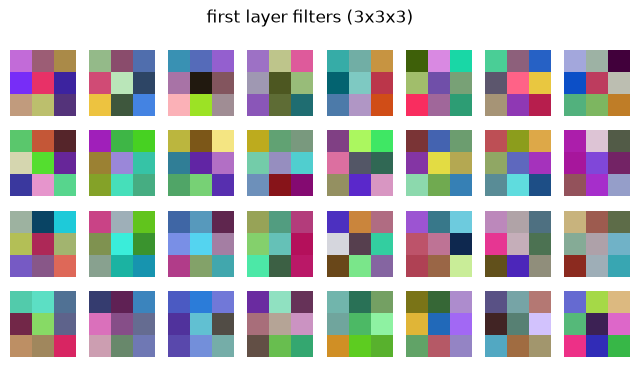

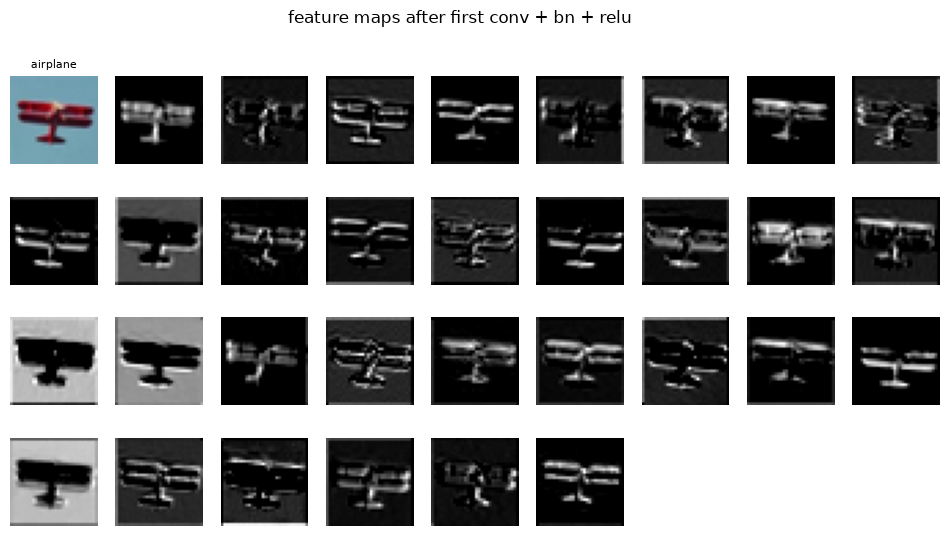

In [2]:
w = model[0].weight.detach().cpu()
w = (w - w.min()) / (w.max() - w.min())

fig, axes = plt.subplots(4, 8, figsize=(8, 4))
for k, ax in enumerate(axes.flat):
    ax.imshow(w[k].permute(1, 2, 0).numpy())
    ax.axis("off")
plt.suptitle("first layer filters (3x3x3)")
plt.show()

k = 0
img = Xv_g[k:k+1]
with torch.no_grad():
    fmap = model[2](model[1](model[0](img)))[0].cpu()

fig, axes = plt.subplots(4, 9, figsize=(12, 6))
axes[0, 0].imshow(Xv[k])
axes[0, 0].set_title(classes[yv[k]], fontsize=8)
for idx, ax in enumerate(axes.flat):
    ax.axis("off")
    if 1 <= idx <= 32:
        ax.imshow(fmap[idx - 1].numpy(), cmap="gray")
plt.suptitle("feature maps after first conv + bn + relu")
plt.show()

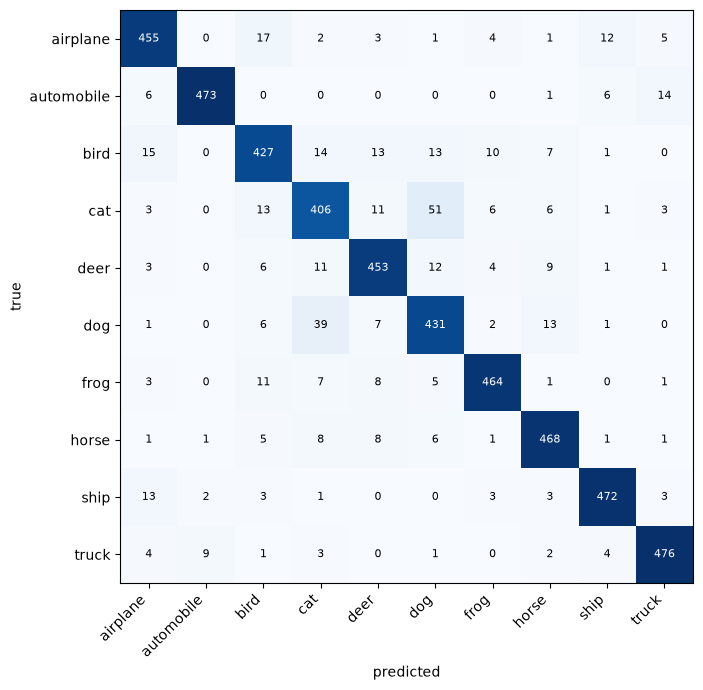

per-class accuracy:
    airplane 0.910
  automobile 0.946
        bird 0.854
         cat 0.812
        deer 0.906
         dog 0.862
        frog 0.928
       horse 0.936
        ship 0.944
       truck 0.952

top 6 confusions (true -> predicted):
         cat -> dog        51
         dog -> cat        39
    airplane -> bird       17
        bird -> airplane   15
        bird -> cat        14
  automobile -> truck      14


In [3]:
model.eval()
with torch.no_grad():
    pred_v = model(Xv_g).argmax(1).cpu().numpy()

cm = np.zeros((10, 10), dtype=int)
for t, p in zip(yv, pred_v):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(classes)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > 250 else "black", fontsize=8)
plt.tight_layout()
plt.show()

print("per-class accuracy:")
for i, name in enumerate(classes):
    print(f"  {name:>10} {cm[i, i] / cm[i].sum():.3f}")

off = [(cm[i, j], classes[i], classes[j]) for i in range(10) for j in range(10) if i != j]
print("\ntop 6 confusions (true -> predicted):")
for n, a, b in sorted(off, reverse=True)[:6]:
    print(f"  {a:>10} -> {b:<10} {n}")

In [4]:
Xte_g, yte_g = Xte_t.to(device), yte_t.to(device)
tl, ta = evaluate(model, Xte_g, yte_g)
print(f"TEST | loss {tl:.3f} | acc {ta:.4f}")

TEST | loss 0.330 | acc 0.8976


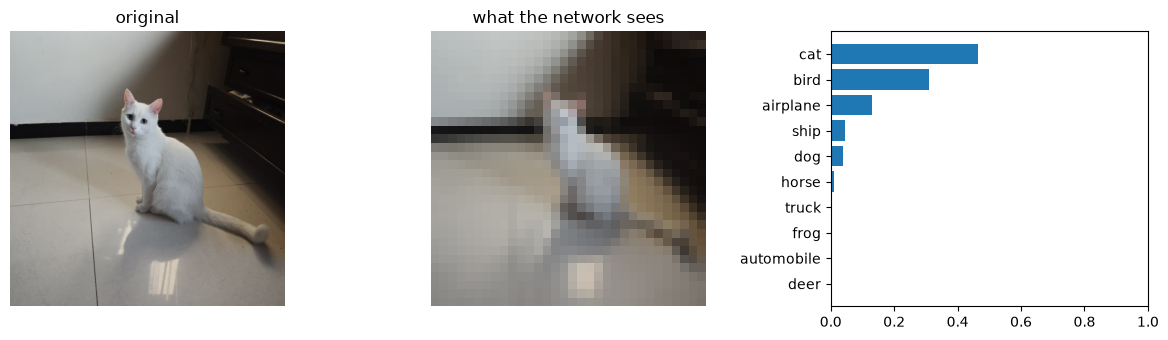

         cat 0.464
        bird 0.310
    airplane 0.129


In [6]:
from PIL import Image

def predict_image(path):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    s = min(w, h)
    img = img.crop(((w - s) // 2, (h - s) // 2, (w + s) // 2, (h + s) // 2))
    small = np.array(img.resize((32, 32), Image.BILINEAR))

    x = prep(small[None]).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0].cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    axes[0].imshow(img); axes[0].set_title("original"); axes[0].axis("off")
    axes[1].imshow(small); axes[1].set_title("what the network sees"); axes[1].axis("off")
    order = np.argsort(probs)
    axes[2].barh([classes[i] for i in order], probs[order])
    axes[2].set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

    for i in order[::-1][:3]:
        print(f"  {classes[i]:>10} {probs[i]:.3f}")

predict_image("my_cat.jpg")

In [8]:
c100 = datasets.CIFAR100(root="./data", train=False, download=True)
X100, y100 = c100.data, np.array(c100.targets)
names100 = c100.classes

def predict_batch(X):
    model.eval()
    with torch.no_grad():
        return torch.softmax(model(prep(X).to(device)), dim=1).cpu().numpy()

p_in = predict_batch(Xte)
print(f"baseline (CIFAR-10 test) | mean confidence {p_in.max(1).mean():.3f}\n")

near = ["wolf", "fox", "leopard", "tiger", "lion", "pickup_truck", "bus", "tractor", "rocket"]
far = ["apple", "chair", "clock", "keyboard", "sunflower", "bottle", "television"]

def report(group_name, group):
    print(f"=== {group_name} ===")
    confs = []
    for name in group:
        c = names100.index(name)
        P = predict_batch(X100[y100 == c])
        conf = P.max(1).mean()
        confs.append(conf)
        top = np.bincount(P.argmax(1), minlength=10).argmax()
        share = (P.argmax(1) == top).mean()
        print(f"  {name:>13} | confidence {conf:.3f} | mostly -> {classes[top]:<10} ({share:.0%})")
    print(f"  group mean confidence {np.mean(confs):.3f}\n")

report("near", near)
report("far", far)

100.0%


baseline (CIFAR-10 test) | mean confidence 0.937

=== near ===
           wolf | confidence 0.800 | mostly -> cat        (54%)
            fox | confidence 0.766 | mostly -> deer       (35%)
        leopard | confidence 0.794 | mostly -> frog       (38%)
          tiger | confidence 0.749 | mostly -> cat        (37%)
           lion | confidence 0.789 | mostly -> dog        (51%)
   pickup_truck | confidence 0.911 | mostly -> automobile (64%)
            bus | confidence 0.912 | mostly -> truck      (75%)
        tractor | confidence 0.824 | mostly -> truck      (58%)
         rocket | confidence 0.740 | mostly -> ship       (47%)
  group mean confidence 0.809

=== far ===
          apple | confidence 0.764 | mostly -> bird       (35%)
          chair | confidence 0.752 | mostly -> airplane   (35%)
          clock | confidence 0.786 | mostly -> cat        (19%)
       keyboard | confidence 0.756 | mostly -> cat        (22%)
      sunflower | confidence 0.803 | mostly -> bird       (37%